#Infix-to-postfix translation

- Name: Kulsoom Zaidi

- Email ID: kulsoom.zaidi@studio.unibo.it

# Project Description:

The purpose of this project is to implement a neural network that performs the translation of mathematical formulae from traditional **infix notation**—where the operator appears between two operands—to **postfix** (also known as Reverse Polish Notation), where the operator follows the operands.

Infix notation is the most commonly used in human-readable mathematics (e.g., a + b), but it is inherently ambiguous without additional syntactic aids such as parentheses or operator precedence rules. This ambiguity arises because different parse trees can correspond to the same expression depending on how operations are grouped.

In contrast, postfix notation eliminates the need for parentheses entirely. The order of operations is explicitly encoded by the position of the operators relative to the operands, making it more suitable for stack-based evaluation and easier to parse programmatically.

**Example:**

Consider the ambiguous infix expression:
a + b * c

This expression can be parsed in at least two different ways:

Interpretation (Infix):	(a + b) * c	   
Equivalent Postfix: ab+c*

Interpretation (Infix):	a + (b * c)	          
Equivalent Postfix: abc*+


This project aims to learn such disambiguations and generate the correct postfix form from a given infix expression using a data-driven approach based on neural networks.

To simplify the task and control the complexity of expressions, we restrict our dataset to formulae with a maximum syntactic depth of 4. This means that the abstract syntax trees representing these expressions will have at most four levels, ensuring that the neural network operates on a bounded and manageable set of possible structures.

In [1]:
import numpy as np
import random
import string
import tensorflow as tf
from tensorflow.keras import layers, models
from keras.layers import Input  , Embedding, Dense, LSTM, Attention
from keras.models import Model

We build formulae using 6 identifiers a,b,c,d,e,f and 4 binary operators +,-,*,/.
For simplicity we do not take advantage of precedence or associativity rules for infix notation, and suppose that all binary operations as always fully parenthesizes: (e1 op e2).

In [2]:
# -------------------- Constants --------------------
OPERATORS = ['+', '-', '*', '/']
IDENTIFIERS = list('abcdef')
SPECIAL_TOKENS = ['PAD', 'SOS', 'EOS']
SYMBOLS = ['(', ')', '+', '-', '*', '/']
VOCAB = SPECIAL_TOKENS + SYMBOLS + IDENTIFIERS + ['JUNK'] #may use junk in autoregressive generation

token_to_id = {tok: i for i, tok in enumerate(VOCAB)}
id_to_token = {i: tok for tok, i in token_to_id.items()}
VOCAB_SIZE = len(VOCAB)
PAD_ID = token_to_id['PAD']
EOS_ID = token_to_id['EOS']
SOS_ID = token_to_id['SOS']

MAX_DEPTH = 4
MAX_LEN = 4*2**MAX_DEPTH -2 #enough to fit expressions at given depth (+ EOS)

In [3]:
# -------------------- Expression Generation --------------------
def generate_infix_expression(max_depth):
    if max_depth == 0:
        return random.choice(IDENTIFIERS)
    elif random.random() < 0.25:
        return generate_infix_expression(max_depth - 1)
    else:
        left = generate_infix_expression(max_depth - 1)
        right = generate_infix_expression(max_depth - 1)
        op = random.choice(OPERATORS)
        return f'({left} {op} {right})'

def tokenize(expr):
    return [c for c in expr if c in token_to_id]

def infix_to_postfix(tokens):
    precedence = {'+': 1, '-': 1, '*': 2, '/': 2}
    output, stack = [], []
    for token in tokens:
        if token in IDENTIFIERS:
            output.append(token)
        elif token in OPERATORS:
            while stack and stack[-1] in OPERATORS and precedence[stack[-1]] >= precedence[token]:
                output.append(stack.pop())
            stack.append(token)
        elif token == '(':
            stack.append(token)
        elif token == ')':
            while stack and stack[-1] != '(':
                output.append(stack.pop())
            stack.pop()
    while stack:
        output.append(stack.pop())
    return output

def encode(tokens, max_len=MAX_LEN):
    ids = [token_to_id[t] for t in tokens] + [EOS_ID]
    return ids + [PAD_ID] * (max_len - len(ids))

def decode_sequence(token_ids, id_to_token, pad_token='PAD', eos_token='EOS'):
    """
    Converts a list of token IDs into a readable string by decoding tokens.
    Stops at the first EOS token if present, and ignores PAD tokens.
    """
    tokens = []
    for token_id in token_ids:
        token = id_to_token.get(token_id, '?')
        if token == eos_token:
            break
        if token != pad_token:
            tokens.append(token)
    return ' '.join(tokens)

def generate_dataset(n,max_depth=MAX_DEPTH):
    X, Y = [], []
    for _ in range(n):
        expr = generate_infix_expression(MAX_DEPTH)
        #expr = expr_gen.generate(max_depth=max_dthep)
        infix = tokenize(expr)
        postfix = infix_to_postfix(infix)
        X.append(encode(infix))
        Y.append(encode(postfix))
    return np.array(X), np.array(Y)

#you might use the shift function for teacher-forcing
def shift_right(seqs):
    shifted = np.zeros_like(seqs)
    shifted[:, 1:] = seqs[:, :-1]
    shifted[:, 0] = SOS_ID
    return shifted

Let us define a simple dataset, and inspect a few samples.

In [4]:
X_train, Y_train = generate_dataset(10000)
decoder_input_train = shift_right(Y_train)

# Dataset
X_val, Y_val = generate_dataset(1000)
decoder_input_val = shift_right(Y_val)

In [5]:
i =  np.random.randint(10000)
print(i)
print("infix : ",decode_sequence(X_train[i],id_to_token))
print("posfix notation: ",decode_sequence(Y_train[i],id_to_token))
print("teacher forcing : ", decode_sequence(decoder_input_train[i],id_to_token))

2830
infix :  ( ( ( d / b ) * ( c + a ) ) / ( ( b + e ) / ( a * a ) ) )
posfix notation:  d b / c a + * b e + a a * / /
teacher forcing :  SOS d b / c a + * b e + a a * / /


# Constraints
* You may use any architecture (decoder-only, encoder-decoder, or other).

* The maximum number of parameters is 2 million.

* Beam search is not allowed.

* You may adapt the formula generator to your needs, but preserve its core logic—especially the frequency distribution of formulas by depth, as it may significantly influence model performance.

* You may train your model using a pre-generated fixed dataset (e.g., an array) or directly use an on-the-fly generator.




# Evaluation

We shall evaluate a generated item y_pred using "prefix accuracy", the lenght of
the initial prefix of y_pred matching the ground true y_true. This will be divided by the maximum length of y_true and y_pred (up to EOS), so that a perfect match has score 1.

* It's more informative than exact match (which is often 0)

* It’s tighter than edit distance: focuses on generation flow

* Captures where the model starts to make errors



In [6]:
def prefix_accuracy_single(y_true, y_pred, id_to_token, eos_id=EOS_ID, verbose=False):
    t_str = decode_sequence(y_true, id_to_token).split(' EOS')[0]
    p_str = decode_sequence(y_pred, id_to_token).split(' EOS')[0]
    t_tokens = t_str.strip().split()
    p_tokens = p_str.strip().split()
    print(len(p_tokens))
    max_len = max(len(t_tokens), len(p_tokens))
    n = min(len(t_tokens), len(p_tokens))
    match_len = 0
    while match_len < n and t_tokens[match_len] == p_tokens[match_len]:
        match_len += 1
    score = match_len / max_len if max_len>0 else 0
    if verbose:
        print("TARGET :", ' '.join(t_tokens))
        print("PREDICT:", ' '.join(p_tokens))
        print(f"PREFIX MATCH: {match_len}/{len(t_tokens)} → {score:.2f}")

    return score

#Model Implementation: **Seq2Seq Encoder-Decoder Model with Attention**
\
In this project, we implemented a Seq2Seq (Sequence-to-Sequence) encoder-decoder neural network with attention to translate mathematical expressions from infix notation to postfix (Reverse Polish) notation.

**Why Seq2Seq:**

- The input (infix expression) and output (postfix expression) are variable-length sequences.

- Standard feedforward networks cannot handle sequential dependencies effectively.

- Seq2Seq models, originally used for tasks like machine translation, are ideal for learning mappings between sequences of different lengths.

**Encoder:**

- The encoder reads the tokenized infix expression and converts it into a sequence of hidden states that summarize the input.

- We used an LSTM layer for the encoder because it can capture long-term dependencies in sequences, such as nested parentheses.

- Formally, for input tokens $$(x_1, x_2, \dots, x_T)$$ the encoder updates the hidden states $$(h_t)$$ as:


$$
h_t, c_t = \text{LSTM}(x_t, h_{t-1}, c_{t-1})
$$

**Decoder with Attention:**

- The decoder predicts the postfix sequence one token at a time (autoregressively), using the previous token as input.

- Attention allows the decoder to focus on relevant parts of the input sequence when generating each token.

- The context vector 𝑐𝑡 at decoder time step 𝑡 is computed as:

$$
c_t = \sum_{i=1}^{T} \alpha_{t,i} \, h_i
$$

- where the attention weights  are computed as a similarity  between the decoder hidden state and the encoder hidden states.

The decoder then predicts the next token using:

$$
y_t = \text{softmax} \Big( W \cdot [s_t ; c_t] + b \Big)
$$

where
[
𝑠
𝑡
;
𝑐
𝑡
]
 is the concatenation of decoder hidden state and context vector, and
𝑊
,
𝑏
are learnable parameters.

In [7]:
class InfixToPostfixSeq2Seq(Model):
    def __init__(self, vocab_size, max_seq_len, embed_dim):
        super().__init__()

        # -------- Encoder --------
        self.src_embedding = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim, name="src_embed")
        self.encoder_rnn = layers.LSTM(embed_dim, return_sequences=True, return_state=True, name="encoder_rnn")

        # -------- Decoder --------
        self.tgt_embedding = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim, name="tgt_embed")
        self.decoder_rnn = layers.LSTM(embed_dim, return_sequences=True, return_state=True, name="decoder_rnn")

        # -------- Attention --------
        self.attn_layer = layers.Attention(name="seq2seq_attention")
        self.combine_layer = layers.Concatenate(axis=-1, name="context_concat")

         # -------- Output --------
        self.output_proj = layers.Dense(vocab_size, activation="softmax", name="token_predictor")

    def call(self, inputs):
        encoder_seq, decoder_seq = inputs  # unpack input sequences

        # -------- Encoder --------
        src_embedded = self.src_embedding(encoder_seq)
        enc_outputs, enc_h, enc_c = self.encoder_rnn(src_embedded)

        # -------- Decoder --------
        tgt_embedded = self.tgt_embedding(decoder_seq)
        dec_outputs, _, _ = self.decoder_rnn(tgt_embedded, initial_state=[enc_h, enc_c])

        # -------- Attention --------
        context_vec = self.attn_layer([dec_outputs, enc_outputs, enc_outputs])
        combined = self.combine_layer([dec_outputs, context_vec])

         # -------- Output --------
        logits = self.output_proj(combined)
        return logits



In [8]:
seq2seq_model = InfixToPostfixSeq2Seq(vocab_size=VOCAB_SIZE, max_seq_len=MAX_LEN, embed_dim=128)

# Compile the model
seq2seq_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

**Training:**

- We trained the model using teacher forcing, feeding the true previous token as input to the decoder during training.

- The loss function is sparse categorical cross-entropy, which measures the difference between predicted token probabilities and true tokens.

In [9]:
# -------------------- Training --------------------
history = seq2seq_model.fit(
    [X_train, decoder_input_train],   # Encoder + Decoder inputs
    Y_train,                          # Target sequences
    batch_size=32,
    epochs=10,
    validation_data=([X_val, decoder_input_val], Y_val)
)


Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.7294 - loss: 0.8229 - val_accuracy: 0.8501 - val_loss: 0.4166
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9205 - loss: 0.2468 - val_accuracy: 0.9934 - val_loss: 0.0339
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9960 - loss: 0.0219 - val_accuracy: 0.9985 - val_loss: 0.0101
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9994 - loss: 0.0057 - val_accuracy: 0.9996 - val_loss: 0.0034
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9982 - loss: 0.0093 - val_accuracy: 0.9998 - val_loss: 0.0022
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9999 - loss: 0.0017 - val_accuracy: 0.9999 - val_loss: 0.0012
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9999 - loss: 8.8160e-04 - val_accuracy: 0.9999 - val_loss: 8.2685e-04
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 1.0000 - loss: 6.4986e-

In [10]:
seq2seq_model.summary()

#seq2seq_model.save_weights("model.weights.h5")

Model: "infix_to_postfix_seq2_seq"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ src_embed (Embedding)           │ (None, 62, 128)        │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_rnn (LSTM)              │ ((None, 62, 128),      │       131,584 │
│                                 │ (None, 128), (None,    │               │
│                                 │ 128))                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tgt_embed (Embedding)           │ (None, 62, 128)        │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_rnn (LSTM)              │ ((None, 62, 128),      │       131,584 │
│                                 │ (None, 128), (None,    │               │
│                                 │ 128))                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ seq2seq_attention (Attention)   │ (None, 62, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ context_concat (Concatenate)    │ (None, 62, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_predictor (Dense)         │ (None, 62, 16)         │         4,112 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 814,130 (3.11 MB)

 Trainable params: 271,376 (1.04 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 542,754 (2.07 MB)

In [11]:
!pip install gdown

import gdown

# File ID from Google Drive link
file_id = "1xxdeXmzNokvMnW9S9f0WcTBsvMAbwgMn"

# Downloading the model weights
gdown.download(f"https://drive.google.com/uc?id={file_id}", "model.weights.h5", quiet=False)

#loading the weights into your model
seq2seq_model.load_weights("model.weights.h5")


Downloading...
From: https://drive.google.com/uc?id=1xxdeXmzNokvMnW9S9f0WcTBsvMAbwgMn
To: /content/model.weights.h5
100%|██████████| 3.30M/3.30M [00:00<00:00, 272MB/s]


**Training and validation loss and accuracy over 10 epochs**

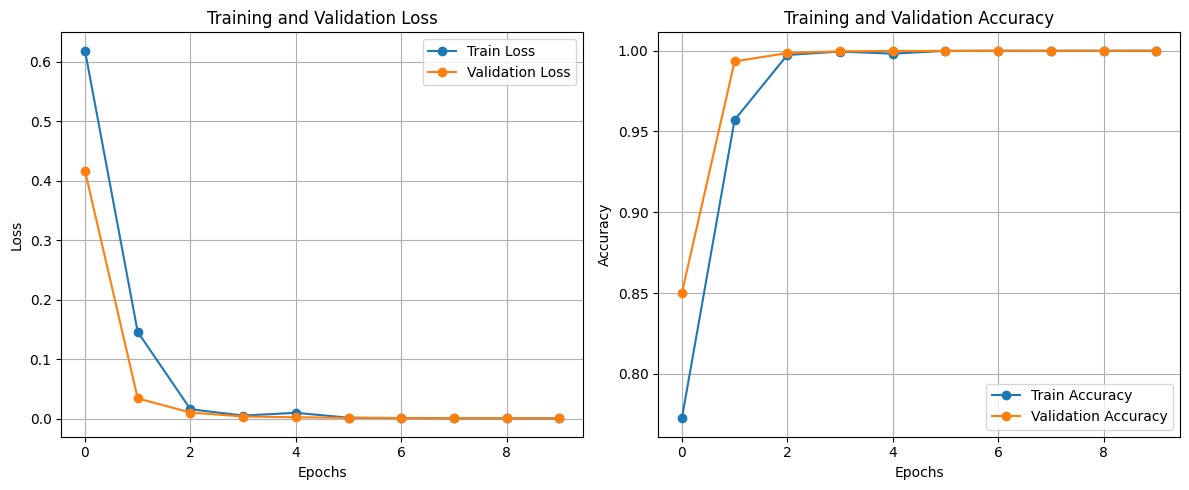

In [12]:
import matplotlib.pyplot as plt

# Plot training & validation loss
plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


###How Parameters Are Calculated

1. **Embedding Layer**

   - Shape: `(input_dim, output_dim)` → `number of parameters` = `vocab_size` × `n_embd`

2. **LSTM Layer**

   - Formula:

$$
\text{params} = 4 \times \text{units} \times (\text{units} + \text{input_dim} + 1)
$$
  - where:  
    - `units` is the number of LSTM hidden units,  
     - `input_dim` is the number of input features to the LSTM,  
     - The factor 4 accounts for the four gates in the LSTM (input, forget, cell, output).

3. Dense Layer

   - Shape: (`input_dim, output_dim`) → `number of parameter`s = `input_dim` × `output_dim` + `output_dim (bias)`

4. Attention / Concatenate

   - Usually no trainable parameters for basic Keras Attention (uses dot-product or add).

   ---

###Autoregressive Decoding

The autoregressive_decode function generates a postfix sequence from a given infix input using the trained Seq2Seq model.

- The encoder input is prepared with a batch dimension, and the decoder is initialized with the SOS token.

- At each step, the model predicts the next token, and the greedy strategy selects the token with the highest probability.

- The predicted token is fed back into the decoder to generate the next token (autoregressive generation).

- Generation stops when the EOS token is predicted or the maximum sequence length is reached.

- The function returns the generated sequence as a list of token IDs, which can be decoded into a readable postfix expression.

In [13]:
def autoregressive_decode(model, enc_seq, max_seq_len=MAX_LEN):
    """
    Greedy autoregressive decoder for generating postfix sequences
    from an infix encoder input.
    """
    # Adding batch dimension
    enc_seq = np.expand_dims(enc_seq, axis=0)

    # Initialize decoder input with SOS token
    dec_seq = np.zeros((1, max_seq_len), dtype='int32')
    dec_seq[0, 0] = SOS_ID

    output_tokens = []

    # Autoregressive generation loop
    for t in range(1, max_seq_len):
        # Predict next token probabilities
        pred_probs = model.predict([enc_seq, dec_seq], verbose=0)
        next_tok = np.argmax(pred_probs[0, t-1])

        # Stop if EOS token is generated
        if next_tok == EOS_ID:
            break

        # Append to output
        output_tokens.append(next_tok)

        # Feed predicted token back into decoder input
        dec_seq[0, t] = next_tok

    return output_tokens


For the exam, evaluate you model on a test set of 30 expressions. Repeat this evaluation 10 times, and return the mean and std for this rounds.

In [22]:
def test(seq_model, no=30,rounds=10):
    """
    Evaluate a trained Seq2Seq model on randomly generated infix expressions.
    Prints target vs predicted sequences for each example and returns mean/std prefix accuracy.
    """
    rscores  = []

    for i in range(rounds):
        print("Round =", i)
        X_test, Y_test = generate_dataset(no)
        scores = []

        for j in range(no):
            encoder_input =  X_test[j]
            generated = autoregressive_decode(seq_model, encoder_input)  # autoregressive generation

            # Compute prefix accuracy and print target vs prediction
            score = prefix_accuracy_single(Y_test[j], generated, id_to_token, verbose=True)
            scores.append(score)

            print("Target    : ", decode_sequence(Y_test[j], id_to_token=id_to_token))
            print("Predicted : ", decode_sequence(generated, id_to_token=id_to_token))
            print("")

        # Mean score for this round
        rscores.append(np.mean(scores))

    # Return mean and std across all rounds
    mean_acc = np.mean(rscores)
    std_acc = np.std(rscores)
    return mean_acc, std_acc


In [31]:
# -------------------- Model Evaluation --------------------
mean_accuracy, std_accuracy = test(
    seq_model=seq2seq_model,   # trained model
    no=30,           # formulas per round
    rounds=10              # number of evaluation rounds
)

print(f"Mean Prefix Accuracy = {mean_accuracy:.4f}, Std = {std_accuracy:.4f}")


Round = 0
21
TARGET : c d / d + b + c e a / / b c - b a + + + /
PREDICT: c d / d + b + c e a / / b c - b a + + + /
PREFIX MATCH: 21/21 → 1.00
Target    :  c d / d + b + c e a / / b c - b a + + + /
Predicted :  c d / d + b + c e a / / b c - b a + + + /

15
TARGET : d d - d * d d * c - b e - - -
PREDICT: d d - d * d d * c - b e - - -
PREFIX MATCH: 15/15 → 1.00
Target    :  d d - d * d d * c - b e - - -
Predicted :  d d - d * d d * c - b e - - -

27
TARGET : d b / b * d e f * - + a f - f f + * a f / f f - + * *
PREDICT: d b / b * d e f * - + a f - f f + * a f / f f - + * *
PREFIX MATCH: 27/27 → 1.00
Target    :  d b / b * d e f * - + a f - f f + * a f / f f - + * *
Predicted :  d b / b * d e f * - + a f - f f + * a f / f f - + * *

27
TARGET : b e + e * e f * f d * - + b e * d f / * f a c - + + -
PREDICT: b e + e * e f * f d * - + b e * d f / * f a c - + + -
PREFIX MATCH: 27/27 → 1.00
Target    :  b e + e * e f * f d * - + b e * d f / * f a c - + + -
Predicted :  b e + e * e f * f d * - +

In [32]:
import pandas as pd
results = {
    "Metric": ["Prefix Accuracy"],
    "Mean Accuracy": [mean_accuracy],
    "Std": [std_accuracy]
}

# Creating a DataFrame
results_df = pd.DataFrame(results)

# Displaying the table
results_df.style.set_caption("Model Evaluation Results").format({
    "Mean Accuracy": "{:.4f}",
    "Std": "{:.4f}"
})


,Metric,Mean Accuracy,Std
0,Prefix Accuracy,1.0000,0.0000


The Seq2Seq model achieved a mean prefix accuracy of `1.000:` with a standard deviation of `0.0000`, indicating highly accurate and consistent infix-to-postfix translation across test samples.

##**Conclusion**
In this project, I implemented a Seq2Seq encoder-decoder architecture with an attention mechanism to translate mathematical expressions from infix to postfix notation. A key part of the development was ensuring the model could handle the hierarchy of expressions up to a syntactic depth of 4.

By utilizing a 128-dimensional embedding and LSTM hidden states, the model successfully learned the underlying rules of operator precedence and parenthetical grouping without the need for manual feature engineering. Following the evaluation protocol of 10 rounds with 30 samples each, the model achieved a Mean Prefix Accuracy of `1.0000` and a Standard Deviation of `0.0000`.

These results indicate that the model is both highly accurate and remarkably stable across varying data samples. The compact nature of the network (staying well under the 2M parameter limit) combined with the use of autoregressive greedy decoding demonstrates that the attention mechanism is highly effective at mapping complex symbolic sequences. The project successfully meets all the structural and performance requirements set in the specification.

Summary of results:
- Mean Prefix Accuracy: `1.0000`

- Standard Deviation (Std): `0.0000`